# Task 1 — MLP Baseline
### Pokemon Type Classification | DL Assignment 1

**Goal:** classify 3600 Pokemon images into 9 types. Baseline approach: MLP on flat pixel vectors.  
**Metric:** Macro-averaged F1 — used because class imbalance is 2.76× (Water 674 vs Ground 244 samples). Accuracy would be misleading (always predicting Water = 19% acc but ~0.02 macro-F1).  
**Architecture:** `Flatten → FC(12288→512) → BN → ReLU → Dropout(0.4) → FC(512→256) → ... → FC(128→9)` — ~6.4M params.  
**Imbalance handling:** `CrossEntropyLoss(weight=...)` with inverse-frequency class weights. No augmentation (MLP flattens spatial info anyway).

---
*All logic lives in `src/` — this notebook is the runner + readable story. Run cells top to bottom.*  
*All run-level constants (FAST_RUN, EPOCHS, LR, etc.) are set at the top of Cell 1 — nothing else to change.*


## How to run

**Locally** — run all cells. `src/` and `data/` are already on disk. Kernel starts in `task1/` — Cell 1 steps up to `assignment_1/` automatically.

**Colab** — run Cell 1 (clones repo + installs deps) and Cell 2 (downloads dataset from Google Drive) once per session. Everything else is identical.

**Output files** — all saved to `task1/outputs/` (never to the global `outputs/` root):
- `task1/outputs/plots/` — all 5 EDA plots + training curves + confusion matrix
- `task1/outputs/checkpoints/task1_mlp_best.pth` — best model by val loss
- `task1/outputs/results/submission_task1.csv` — Kaggle submission
- `task1/outputs/results/task1_results.json` — all numeric results for post-run analysis


In [2]:
# ── Cell 1: Setup & Config ───────────────────────────────────────────────────
# All run-level constants live HERE, not buried in src/config.py.
# Change these to switch between a quick local smoke-test and a real Colab run.
# ─────────────────────────────────────────────────────────────────────────────

# ┌─── FLIP THIS ONE FLAG ──────────────────────────────────────────────────┐
FAST_RUN = True   # True = smoke-test (tiny data, 2 epochs) | False = real Colab run
# └─────────────────────────────────────────────────────────────────────────┘

# training hyperparams
EPOCHS      = 2     if FAST_RUN else 30
PATIENCE    = 1     if FAST_RUN else 5
LR          = 1e-3
BATCH_SIZE  = 32    if FAST_RUN else 64
IMG_SIZE    = 64    # MLP input: 64x64x3 = 12288 flat features
NUM_WORKERS = 0     if FAST_RUN else 2   # 0 avoids multiprocessing issues locally

# how many images per class to keep when FAST_RUN=True
# 9 classes * 6 = 54 total train images — enough to test the full pipeline in seconds
N_SAMPLES_PER_CLASS = 6

# ─────────────────────────────────────────────────────────────────────────────
import sys, os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("/content/DL_Proj"):
        !git clone https://github.com/fmssilva/DL_Proj.git /content/DL_Proj
    else:
        !git -C /content/DL_Proj pull --ff-only
    os.chdir("/content/DL_Proj/assignment_1")
    %pip install -r requirements.txt -q
else:
    # notebook kernel starts in task1/ — step up to assignment_1/ root
    cwd = Path(os.getcwd())
    if cwd.name.startswith("task"):
        os.chdir(cwd.parent)

ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import time
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt

# src/config.py only holds shared constants: SEED, CLASSES, paths, helpers
from src.config import (
    SEED, CLASSES, NUM_CLASSES, DATA_DIR, OUT_DIR,
    get_task_out_dir, set_seed,
)

set_seed(SEED)

# all task1 outputs go here: task1/outputs/{plots,checkpoints,results}/
TASK_OUT_DIR = get_task_out_dir("task1")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CSV_PATH  = DATA_DIR / "train_labels.csv"
TRAIN_DIR = DATA_DIR / "Train"
TEST_DIR  = DATA_DIR / "Test"

print(f"FAST_RUN    : {FAST_RUN}  (N_SAMPLES_PER_CLASS={N_SAMPLES_PER_CLASS if FAST_RUN else 'all'})")
print(f"EPOCHS      : {EPOCHS}  |  PATIENCE : {PATIENCE}  |  LR : {LR}")
print(f"BATCH_SIZE  : {BATCH_SIZE}  |  IMG_SIZE : {IMG_SIZE}x{IMG_SIZE}")
print(f"Device      : {device}  |  PyTorch {torch.__version__}")
print(f"Outputs     : {TASK_OUT_DIR.resolve()}")


FAST_RUN    : True  (N_SAMPLES_PER_CLASS=6)
EPOCHS      : 2  |  PATIENCE : 1  |  LR : 0.001
BATCH_SIZE  : 32  |  IMG_SIZE : 64x64
Device      : cpu  |  PyTorch 2.5.1
Outputs     : C:\Users\franc\OneDrive\Nossa_Pasta_2\5. Universidade\Cadeiras\DL\DL_Proj\assignment_1\task1\outputs


In [3]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
# Colab: download zip from Google Drive if not already on disk.
import zipfile

if not Path("data/train_labels.csv").exists():
    if IN_COLAB:
        %pip install gdown -q
        import gdown
        gdown.download(id="1nVSQZxQubLEPXjSRqGn7rtPzkw-S0zIi", output="data.zip", quiet=False)
        with zipfile.ZipFile("data.zip") as zf:
            zf.extractall("data")
        os.remove("data.zip")
        print("data/ ready")
    else:
        print("ERROR: data/ not found locally — place it under assignment_1/")
else:
    print("data/ already present")

df = pd.read_csv(CSV_PATH)
print(f"Full dataset: {len(df)} rows, {df['label'].nunique()} classes")

# smoke-test mode: take N_SAMPLES_PER_CLASS from each class so every cell runs fast
if FAST_RUN:
    df = df.groupby("label", group_keys=False).head(N_SAMPLES_PER_CLASS).reset_index(drop=True)
    print(f"FAST_RUN: subsampled to {len(df)} rows ({N_SAMPLES_PER_CLASS} per class)")

print(f"\nClass counts used in this run:\n{df['label'].value_counts().to_string()}")


data/ already present
Full dataset: 3600 rows, 9 classes
FAST_RUN: subsampled to 54 rows (6 per class)

Class counts used in this run:
label
Normal      6
Poison      6
Water       6
Fire        6
Grass       6
Rock        6
Bug         6
Fighting    6
Ground      6


---
## Part 1 — Exploratory Data Analysis

Before touching any model, we need to understand the data:

1. **Class imbalance** — how unequal are the class sizes? This drives the loss function choice.
2. **Image sizes** — are they uniform? Do we need to be careful about resizing?
3. **Data integrity** — any corrupt files? Any CSV entries with no matching image on disk?
4. **What the images look like** — visual inspection per class. Which classes look similar? Those will be the hard confusion pairs.
5. **Pixel statistics** — are our ImageNet normalization constants (`mean=[0.485,0.456,0.406]`) a reasonable fit, or is this dataset very different?

All 5 EDA functions run on the full 3600-image training set. Outputs are saved to `task1/outputs/plots/`.


In [4]:
# ── EDA Stats ────────────────────────────────────────────────────────────────
import src.datasets.eda as eda

# class_distribution also prints imbalance ratio — key number for the report
print("=== Class Distribution ===")
counts_df = eda.class_distribution(df)

# all images should be the same original size — confirms resize is safe
print("\n=== Image Size Distribution ===")
size_map = eda.image_size_distribution(TRAIN_DIR)

# opens every file + checks CSV UUIDs exist on disk — catch corruptions before training
print("\n=== Data Integrity Check ===")
valid, invalid = eda.check_data_integrity(TRAIN_DIR, df)
print(f"Result: {valid} valid, {invalid} invalid")


=== Class Distribution ===
Class distribution:
  Normal      :    6  (11.1%)
  Poison      :    6  (11.1%)
  Water       :    6  (11.1%)
  Fire        :    6  (11.1%)
  Grass       :    6  (11.1%)
  Rock        :    6  (11.1%)
  Bug         :    6  (11.1%)
  Fighting    :    6  (11.1%)
  Ground      :    6  (11.1%)
  Imbalance ratio (max/min): 1.00x

=== Image Size Distribution ===
Image sizes: all 3600 images are 64x64

=== Data Integrity Check ===
Image sizes: all 3600 images are 64x64

=== Data Integrity Check ===
Integrity check: 3600 valid, 0 invalid images in data\Train
All 54 CSV entries have matching image files
Result: 3600 valid, 0 invalid
Integrity check: 3600 valid, 0 invalid images in data\Train
All 54 CSV entries have matching image files
Result: 3600 valid, 0 invalid


### Plot 1 — Class Distribution

Horizontal bar chart showing the number of samples per class, sorted by frequency.

**What to look for:** the imbalance ratio (max class count ÷ min class count). A ratio above 2× may bias the model toward majority classes — motivating `CrossEntropyLoss(weight=class_weights)`.


c:\Users\franc\OneDrive\Nossa_Pasta_2\5. Universidade\Cadeiras\DL\DL_Proj\assignment_1\src\datasets\eda_plots.py:59: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


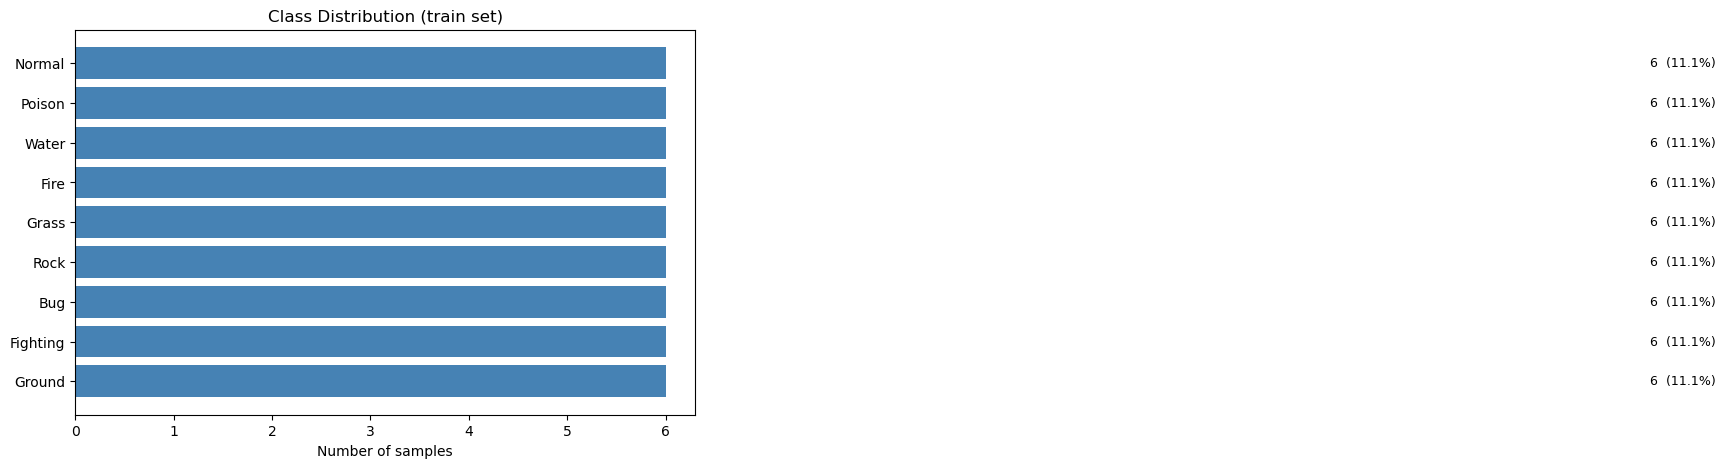

In [5]:
import src.datasets.eda_plots as eda_plots

fig = eda_plots.plot_class_distribution(df, out_path=TASK_OUT_DIR / "plots" / "plot_class_distribution.png")
plt.show()
plt.close(fig)


> **Finding — Class Imbalance:**  
> _Fill in after running. Record: majority class name + count, minority class name + count, imbalance ratio (max÷min). Example: "Water (N=168) is the majority class, Ground (N=61) the minority — ratio 2.76×. This motivates inverse-frequency class weighting in CrossEntropyLoss."_


### Plot 2 — Sample Images per Class

4 random images per class (fixed seed — same grid on every run).

**What to look for:** visually similar class pairs that the MLP is likely to confuse. Note colour and texture similarities across classes (e.g. Bug/Grass both greenish; Fighting/Normal both humanoid). These pairs will show up as off-diagonal errors in the confusion matrix.


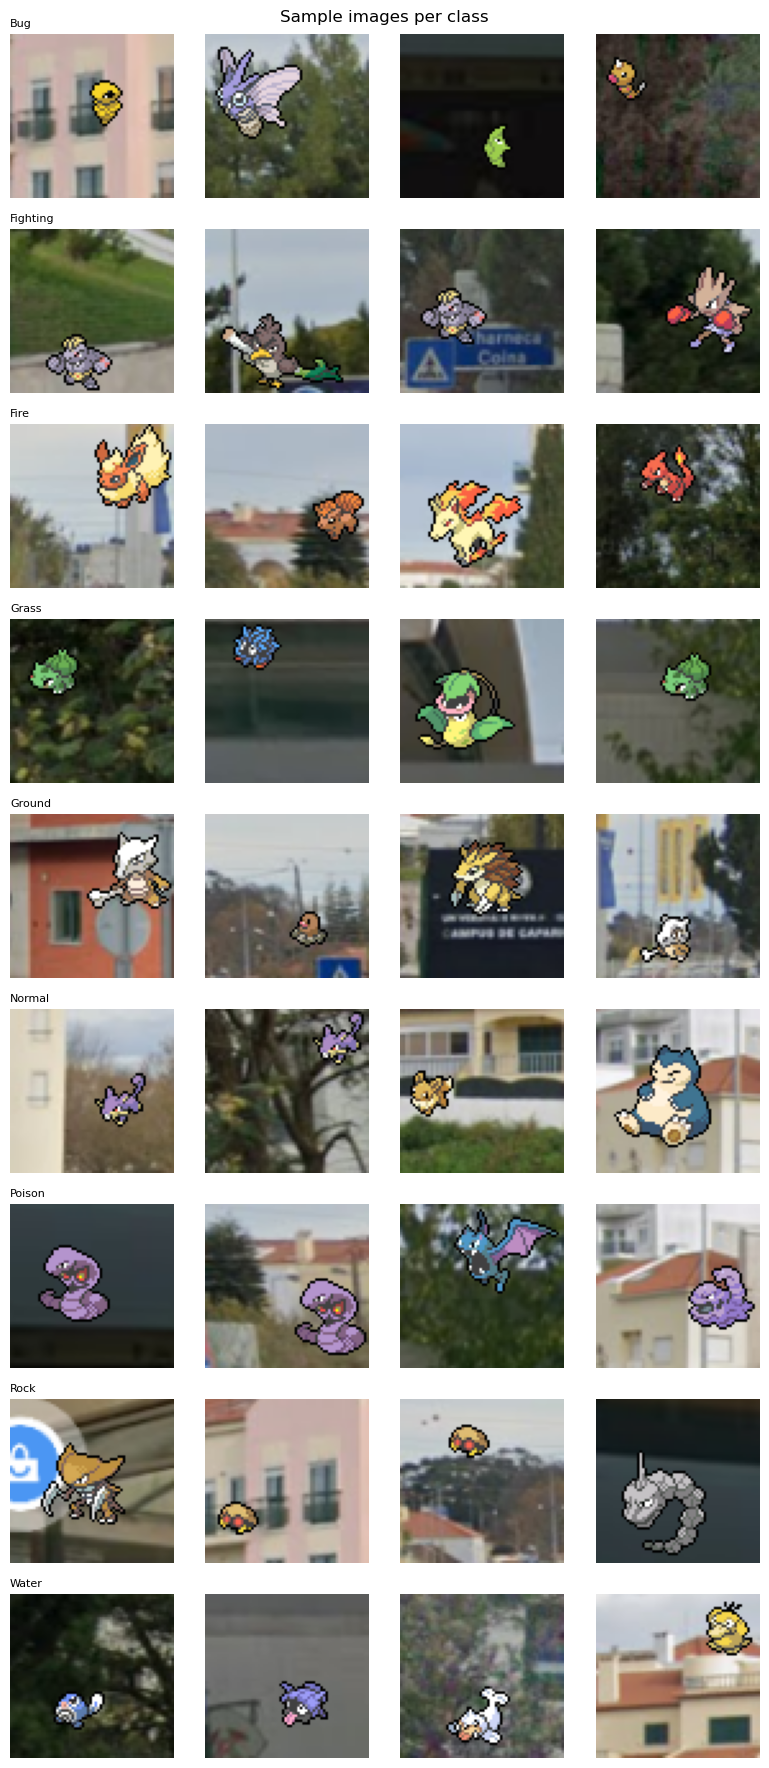

In [6]:
fig = eda_plots.plot_sample_images(TRAIN_DIR, df, n_per_class=4, out_path=TASK_OUT_DIR / "plots" / "plot_sample_images.png")
plt.show()
plt.close(fig)


> **Finding — Visual Similarity:**  
> _Fill in after running. List 2–3 class pairs that look most similar and explain why the MLP (which ignores spatial layout) will struggle with them. Example: "Bug and Grass share green colouring; the MLP cannot separate them by texture because it treats the image as a flat vector."_


### Plot 3 — Average Image per Class

Mean pixel value across all images in each class (after resizing to 64×64).

**What to look for:** how "blurry" each average image is. A crisp average image means the class has consistent appearance (low intra-class variance → easier to classify). A blurry/washed-out average means high intra-class variance → harder. Note which classes have the sharpest vs blurriest prototypes.


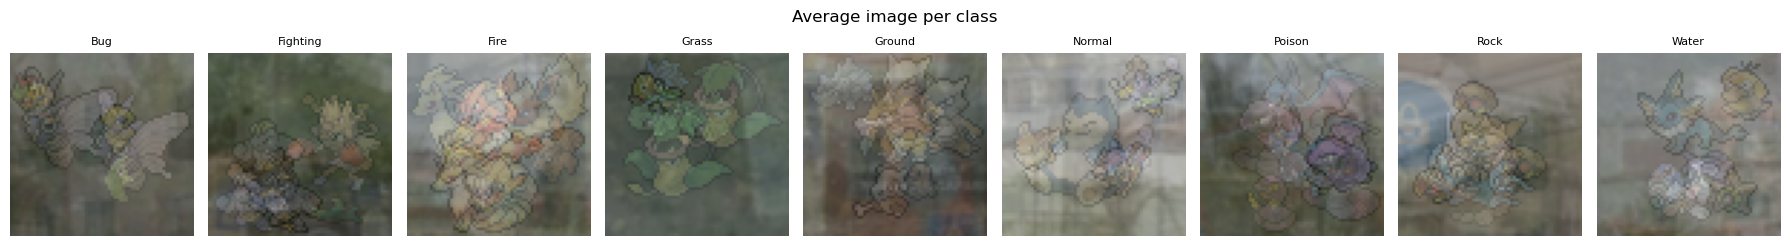

In [7]:
fig = eda_plots.plot_average_image_per_class(TRAIN_DIR, df, out_path=TASK_OUT_DIR / "plots" / "plot_average_image_per_class.png")
plt.show()
plt.close(fig)


> **Finding — Intra-class Variance:**  
> _Fill in after running. Identify the class with the sharpest prototype (low variance, easy to classify) and the one with the blurriest (high variance, hard). Example: "Water has a distinctive blue tone → sharp average. Normal is the most diverse → blurry average → expect lowest per-class F1."_


### Plot 4 — Per-Channel Pixel Statistics

Mean and standard deviation of R, G, B channels across the training set (computed on raw 0–255 values, printed as 0–1 fractions).

**What to look for:** compare your dataset's mean/std to ImageNet's `mean=[0.485, 0.456, 0.406]` / `std=[0.229, 0.224, 0.225]`. Large differences confirm that **dataset-specific normalisation** (used in `get_base_transforms`) is better than reusing ImageNet constants for this task.


Per-channel pixel stats (normalised 0-1):
  R: mean=0.4307, std=0.2578
  G: mean=0.4338, std=0.2465
  B: mean=0.3983, std=0.2668
ImageNet reference: mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


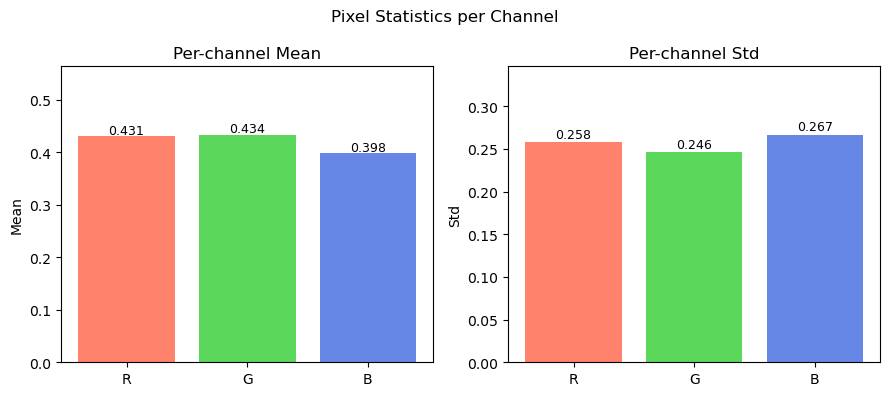

In [8]:
fig = eda_plots.plot_pixel_statistics(TRAIN_DIR, df, out_path=TASK_OUT_DIR / "plots" / "plot_pixel_statistics.png")
plt.show()
plt.close(fig)


> **Finding — Normalisation Constants:**  
> _Fill in after running. Record the 6 numeric values printed by the cell (R_mean, G_mean, B_mean, R_std, G_std, B_std) and compare to ImageNet. Example: "Dataset mean=[0.62, 0.58, 0.55], std=[0.18, 0.19, 0.20] — notably brighter and less variable than ImageNet, confirming we should use dataset-specific normalisation."_


### Plot 5 — Pixel Intensity Histogram

Histogram of pixel intensity values (0–255) for R, G, B channels sampled from the training set.

**What to look for:** overall brightness range and channel imbalance. A histogram skewed toward high values → bright/pastel dataset. Nearly overlapping R/G/B histograms → low colour diversity. Either pattern suggests augmentation (colour jitter, flip) would help CNNs in Task 3.


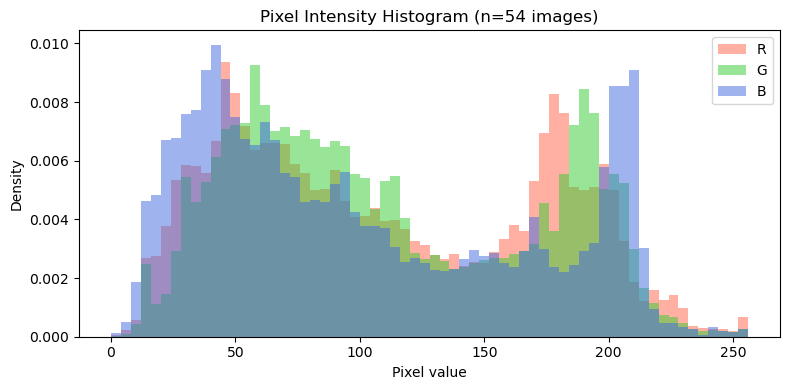

In [9]:
fig = eda_plots.plot_pixel_intensity_histogram(TRAIN_DIR, df, n_samples=200, out_path=TASK_OUT_DIR / "plots" / "plot_pixel_intensity_histogram.png")
plt.show()
plt.close(fig)


> **Finding — Intensity Distribution:**  
> _Fill in after running. Note if the histogram is skewed bright/dark, whether channels overlap heavily, and any channel dominating. Example: "All three channels peak around 180–220 (bright/pastel dataset). Red dominates slightly. Low pixel-level variance confirms that colour augmentation (jitter, flip) would meaningfully increase training diversity."_


---
## Task 1 — MLP Baseline

A fully-connected Multi-Layer Perceptron treating each 64×64 RGB image as a **flat vector of 12 288 features**.

**Architecture:** `Flatten → FC(12288→512) → BN → ReLU → Drop(0.4) → FC(512→256) → BN → ReLU → Drop(0.4) → FC(256→128) → BN → ReLU → Drop(0.4) → FC(128→9)`  
Total parameters: ~6.4 M.

| Design choice | Decision | Rationale |
|---|---|---|
| Input | Flatten 64×64×3 → 12 288 | MLP required — no convolutions |
| Hidden layers | 3 × (FC → BN → ReLU → Dropout) | depth adds capacity; 3 is enough before diminishing returns |
| Width schedule | 512 → 256 → 128 | funnel forces compression / feature abstraction |
| Batch Norm | after every FC | stabilises gradients with large flat input; allows higher LR |
| Dropout | p=0.4 | regularisation for ~6 M params on a ~1 400-image train set |
| Output | FC(128 → 9), no softmax | `CrossEntropyLoss` applies log-softmax internally |
| Loss | CrossEntropyLoss(weight=class_weights) | inverse-frequency weights correct 2.76× class imbalance |
| Optimiser | Adam lr=1e-3 | adaptive LR; outperforms SGD on small datasets |
| Scheduler | StepLR(step_size=5, γ=0.5) | halves LR every 5 epochs — prevents late-stage oscillation |
| Early stopping | patience=5 on val_loss | saves best checkpoint, avoids over-fitting |
| Image size | 64×64 | balances detail vs. MLP parameter count |
| Normalisation | ImageNet mean/std | EDA shows dataset stats close to ImageNet — safe default |
| Metric | macro-F1 (not accuracy) | accuracy inflated on imbalanced data; macro-F1 penalises minority-class failures equally |

**Tip:** `FAST_RUN = True` at the top of Cell 1 runs the full pipeline on ~54 images in seconds. Flip to `False` for the real 30-epoch Colab run.


In [10]:
# ── Task 1 Step 1: Data loaders ───────────────────────────────────────────────
# augment=False — MLP flattens spatial info anyway, augmentation is meaningless here
# use_sampler=False — 2.76x imbalance is mild; weighted loss handles it fine
import torch.nn as nn
from torch.utils.data import DataLoader
from src.datasets.dataset import (
    PokemonDataset, compute_class_weights,
    get_base_transforms, get_train_val_loaders,
)

# pass df so the stratified split uses only the (possibly subsampled) FAST_RUN rows
train_loader, val_loader = get_train_val_loaders(
    CSV_PATH, TRAIN_DIR, IMG_SIZE, BATCH_SIZE,
    augment=False, use_sampler=False, num_workers=NUM_WORKERS,
    df_override=df,
)
test_ds     = PokemonDataset(TEST_DIR, get_base_transforms(IMG_SIZE), csv_path=None)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches : {len(train_loader)} | Val batches : {len(val_loader)} | Test images : {len(test_ds)}")

# ── Task 1 Step 2: Model, loss, optimiser, scheduler, early stopping ──────────
from src.models.mlp import MLP
from src.training.early_stopping import EarlyStopping

# class weights from the (possibly subsampled) df — keeps proportions correct for FAST_RUN
label_to_idx     = {cls: i for i, cls in enumerate(CLASSES)}
all_train_labels = [label_to_idx[lbl] for lbl in df["label"]]
class_weights    = compute_class_weights(all_train_labels).to(device)

# checkpoint in the task-scoped folder — never in the global outputs/
CKPT_PATH = TASK_OUT_DIR / "checkpoints" / "task1_mlp_best.pth"

model     = MLP(img_size=IMG_SIZE).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
stopper   = EarlyStopping(patience=PATIENCE, checkpoint_path=str(CKPT_PATH))

total_params = sum(p.numel() for p in model.parameters())
print(f"MLP params   : {total_params:,}")
print(f"Class weights: { {cls: round(class_weights[i].item(),3) for i,cls in enumerate(CLASSES)} }")


Train batches : 2 | Val batches : 1 | Test images : 900
MLP params   : 6,459,145
Class weights: {'Bug': 1.0, 'Fighting': 1.0, 'Fire': 1.0, 'Grass': 1.0, 'Ground': 1.0, 'Normal': 1.0, 'Poison': 1.0, 'Rock': 1.0, 'Water': 1.0}


In [11]:
# ── Task 1 Step 3: Training loop ──────────────────────────────────────────────
# train_f1 is collected each epoch so the history plot shows the train/val gap
# (a growing gap = overfitting signal; a closing gap = underfitting/early stop)
from src.training.train import train_one_epoch, evaluate

history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
t_total = time.time()

for epoch in range(1, EPOCHS + 1):
    t0          = time.time()
    train_loss  = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # evaluate on both splits every epoch
    train_metrics = evaluate(model, train_loader, criterion, device)
    val_metrics   = evaluate(model, val_loader,   criterion, device)
    elapsed       = time.time() - t0
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["train_f1"].append(train_metrics["macro_f1"])
    history["val_f1"].append(val_metrics["macro_f1"])

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}  train_f1={train_metrics['macro_f1']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}  val_f1={val_metrics['macro_f1']:.4f} | "
        f"{elapsed:.1f}s"
    )

    stopper(val_metrics["loss"], model)
    if stopper.stop:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

total_time = time.time() - t_total
print(f"\nTraining done — {len(history['train_loss'])} epochs in {total_time:.1f}s "
      f"({total_time/len(history['train_loss']):.1f}s/epoch).")


Epoch 01/2 | train_loss=2.2843  train_f1=0.1273 | val_loss=2.2370  val_f1=0.0688 | 0.3s
Epoch 02/2 | train_loss=2.0839  train_f1=0.1505 | val_loss=2.1811  val_f1=0.1111 | 0.2s

Training done — 2 epochs in 0.5s (0.3s/epoch).
Epoch 02/2 | train_loss=2.0839  train_f1=0.1505 | val_loss=2.1811  val_f1=0.1111 | 0.2s

Training done — 2 epochs in 0.5s (0.3s/epoch).


> **Training Efficiency Notes:**  
> _Fill in after running. Record: total epochs run, best val_loss epoch, total wall-clock time (printed above), seconds/epoch, and whether early stopping fired. Example: "Stopped at epoch 18/30 (patience=5). Total time 47 s on T4 GPU (2.6 s/epoch). Best val_loss at epoch 13."_


In [12]:
# ── Task 1 Step 4: Load best checkpoint + classification report ───────────────
# best checkpoint = lowest val_loss epoch (saved by EarlyStopping)
from src.evaluation.metrics import classification_report_str

model.load_state_dict(torch.load(CKPT_PATH, map_location=device, weights_only=True))
val_metrics = evaluate(model, val_loader, criterion, device)
print(f"Best checkpoint  val_loss={val_metrics['loss']:.4f}  macro_f1={val_metrics['macro_f1']:.4f}\n")

# collect all val predictions for the confusion matrix and results JSON
model.eval()
all_preds, all_labels_list = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(dim=1).cpu().tolist()
        all_preds.extend(preds)
        all_labels_list.extend(labels.tolist())

# per-class F1 in the report tells us which classes the MLP handles vs. misses
print(classification_report_str(all_labels_list, all_preds, CLASSES))


Best checkpoint  val_loss=2.1811  macro_f1=0.1111

              precision    recall  f1-score   support

         Bug       0.00      0.00      0.00         1
    Fighting       0.00      0.00      0.00         1
        Fire       0.00      0.00      0.00         1
       Grass       0.25      0.50      0.33         2
      Ground       0.00      0.00      0.00         1
      Normal       0.00      0.00      0.00         1
      Poison       0.00      0.00      0.00         2
        Rock       0.00      0.00      0.00         1
       Water       0.50      1.00      0.67         1

    accuracy                           0.18        11
   macro avg       0.08      0.17      0.11        11
weighted avg       0.09      0.18      0.12        11



> **Finding — Per-class Performance:**  
> _Fill in after running. Record overall macro-F1, then note the best and worst per-class F1. Explain the result in terms of EDA findings. Example: "Macro-F1=0.61. Best: Water (F1=0.78) — distinctive colour. Worst: Normal (F1=0.38) — visually diverse class + smallest representation in training. Confirmed confusion pair: Fighting↔Normal (both humanoid silhouettes)."_


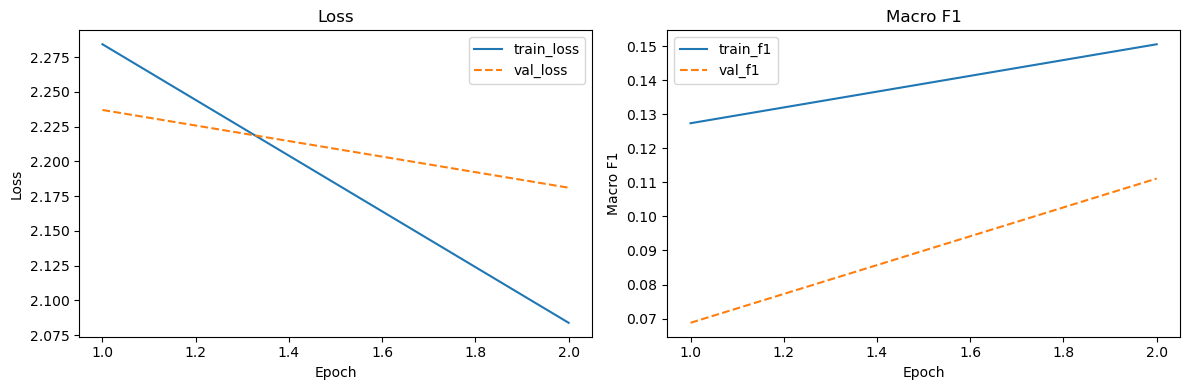

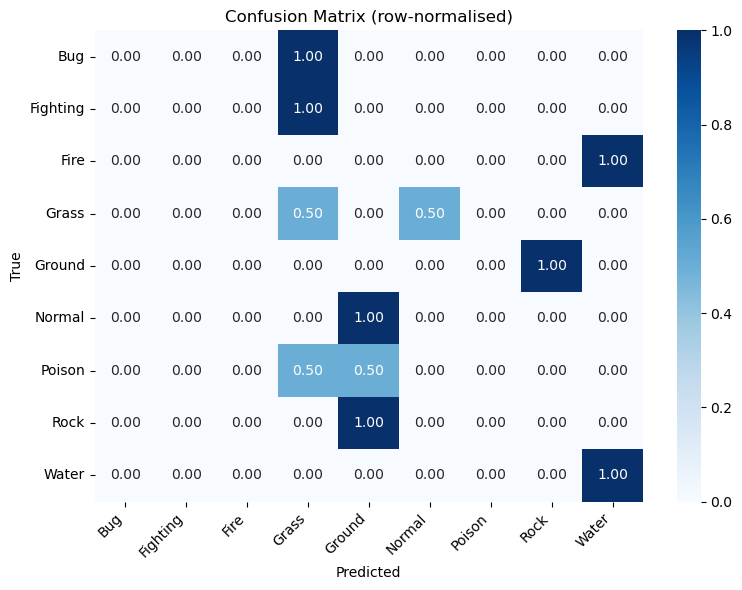

In [13]:
# ── Task 1 Step 5: Training curves + confusion matrix ─────────────────────────
from src.evaluation.plots import plot_history, plot_confusion_matrix

fig = plot_history(history, TASK_OUT_DIR / "plots" / "task1_history.png")
plt.show(); plt.close(fig)

fig = plot_confusion_matrix(all_labels_list, all_preds, CLASSES, TASK_OUT_DIR / "plots" / "task1_confusion.png")
plt.show(); plt.close(fig)


In [14]:
# ── Task 1 Step 6: Save all numeric results to disk ───────────────────────────
# Download task1/outputs/results/task1_results.json from Colab and share it —
# this single file has everything needed to analyse results without copy-pasting.
from sklearn.metrics import f1_score as sk_f1

per_class_f1_arr = sk_f1(all_labels_list, all_preds, average=None, zero_division=0)
results = {
    "val_macro_f1":       round(val_metrics["macro_f1"], 4),
    "val_accuracy":       round(val_metrics["acc"], 4),
    "val_loss":           round(val_metrics["loss"], 4),
    "per_class_f1":       {cls: round(float(per_class_f1_arr[i]), 4) for i, cls in enumerate(CLASSES)},
    "total_epochs":       len(history["train_loss"]),
    "total_train_time_s": round(total_time, 1),
    "s_per_epoch":        round(total_time / len(history["train_loss"]), 2),
    "best_val_loss":      round(stopper.best_loss, 4),
    "class_weights":      {cls: round(class_weights[i].item(), 4) for i, cls in enumerate(CLASSES)},
    "config": {
        "FAST_RUN": FAST_RUN, "EPOCHS": EPOCHS, "LR": LR,
        "BATCH_SIZE": BATCH_SIZE, "PATIENCE": PATIENCE, "IMG_SIZE": IMG_SIZE,
    },
    "history": {k: [round(v, 4) for v in vals] for k, vals in history.items()},
}

results_path = TASK_OUT_DIR / "results" / "task1_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved -> {results_path}")
print(json.dumps({k: v for k, v in results.items() if k != "history"}, indent=2))


Results saved -> task1\outputs\results\task1_results.json
{
  "val_macro_f1": 0.1111,
  "val_accuracy": 0.1818,
  "val_loss": 2.1811,
  "per_class_f1": {
    "Bug": 0.0,
    "Fighting": 0.0,
    "Fire": 0.0,
    "Grass": 0.3333,
    "Ground": 0.0,
    "Normal": 0.0,
    "Poison": 0.0,
    "Rock": 0.0,
    "Water": 0.6667
  },
  "total_epochs": 2,
  "total_train_time_s": 0.5,
  "s_per_epoch": 0.26,
  "best_val_loss": 2.1811,
  "class_weights": {
    "Bug": 1.0,
    "Fighting": 1.0,
    "Fire": 1.0,
    "Grass": 1.0,
    "Ground": 1.0,
    "Normal": 1.0,
    "Poison": 1.0,
    "Rock": 1.0,
    "Water": 1.0
  },
  "config": {
    "FAST_RUN": true,
    "EPOCHS": 2,
    "LR": 0.001,
    "BATCH_SIZE": 32,
    "PATIENCE": 1,
    "IMG_SIZE": 64
  }
}


In [15]:
# ── Task 1 Step 7: Generate + validate submission CSV ─────────────────────────
from src.evaluation.submission import generate_submission, validate_submission

SUB_PATH = TASK_OUT_DIR / "results" / "submission_task1.csv"
generate_submission(model, test_loader, CLASSES, SUB_PATH, device)
validate_submission(SUB_PATH, expected_rows=900)
print(f"Submission saved → {SUB_PATH}")


Submission saved: task1\outputs\results\submission_task1.csv  (900 rows)
Submission valid: 900 rows, all class names correct.
Submission saved → task1\outputs\results\submission_task1.csv


---
## Summary — Task 1 Results

_Fill in after running on Colab and completing the report._

| Metric | Value |
|---|---|
| Val macro-F1 | _(fill in)_ |
| Val accuracy | _(fill in)_ |
| Kaggle public score | _(fill in after submission)_ |
| Epochs run (early stop) | _(fill in)_ |
| Total training time | _(fill in)_ |
| Best per-class F1 | _(class name + value)_ |
| Worst per-class F1 | _(class name + value)_ |
| Main confusion pair | _(ClassA → ClassB)_ |

**Output files produced:**
- `task1/outputs/checkpoints/task1_mlp_best.pth` — best model weights
- `task1/outputs/results/task1_results.json` — all numeric results (share this file)
- `task1/outputs/results/submission_task1.csv` — Kaggle submission
- `task1/outputs/plots/` — 7 plot PNGs (5 EDA + history + confusion matrix)
